In [ ]:
# Imports: libraries for data, ML/NLP, and plotting
import pandas as pd
# Imports: libraries for data, ML/NLP, and plotting
import numpy as np
# Imports: libraries for data, ML/NLP, and plotting
import copy
# Imports: libraries for data, ML/NLP, and plotting
import re
# Imports: libraries for data, ML/NLP, and plotting
import string
# Imports: libraries for data, ML/NLP, and plotting
import nltk
# Imports: libraries for data, ML/NLP, and plotting
from nltk.corpus import stopwords
# Imports: libraries for data, ML/NLP, and plotting
from nltk.tokenize import word_tokenize
# Imports: libraries for data, ML/NLP, and plotting
# Text preprocessing / vectorization
from nltk.stem import PorterStemmer
# Imports: libraries for data, ML/NLP, and plotting
from gensim import corpora, models
# Imports: libraries for data, ML/NLP, and plotting
# Topic modeling step
from gensim.models import LdaModel
# Imports: libraries for data, ML/NLP, and plotting
from gensim.models.coherencemodel import CoherenceModel
# Imports: libraries for data, ML/NLP, and plotting
import spacy
# Imports: libraries for data, ML/NLP, and plotting
import matplotlib.pyplot as plt  # For plotting coherence values
# Imports: libraries for data, ML/NLP, and plotting
import seaborn as sns
# Imports: libraries for data, ML/NLP, and plotting
# Text preprocessing / vectorization
# Numerical / scientific computation
from sklearn.feature_extraction.text import CountVectorizer
# Imports: libraries for data, ML/NLP, and plotting
# Text preprocessing / vectorization
# Numerical / scientific computation
from sklearn.feature_extraction.text import TfidfVectorizer
# Imports: libraries for data, ML/NLP, and plotting
from nltk.corpus import wordnet
# Imports: libraries for data, ML/NLP, and plotting
from nltk.corpus import wordnet as wn
# Imports: libraries for data, ML/NLP, and plotting
from google.colab import drive
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
drive.mount('/content/drive')
# Imports: libraries for data, ML/NLP, and plotting
from gensim.models import Word2Vec
# Imports: libraries for data, ML/NLP, and plotting
# Numerical / scientific computation
from scipy.stats import pearsonr
# Imports: libraries for data, ML/NLP, and plotting
# Numerical / scientific computation
from scipy.stats import spearmanr
# Imports: libraries for data, ML/NLP, and plotting
import time
# Imports: libraries for data, ML/NLP, and plotting
import kagglehub
# Imports: libraries for data, ML/NLP, and plotting
from gensim.test.utils import datapath
# Imports: libraries for data, ML/NLP, and plotting
import os
# Imports: libraries for data, ML/NLP, and plotting
import gensim
# Imports: libraries for data, ML/NLP, and plotting
import random
# Imports: libraries for data, ML/NLP, and plotting
import gensim.downloader as api
# Imports: libraries for data, ML/NLP, and plotting
from gensim.models import KeyedVectors
# Imports: libraries for data, ML/NLP, and plotting
import spacy
spacy.cli.download("en_core_web_lg")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Mounted at /content/drive
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
#!pip install --upgrade numpy gensim
#import os
#os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 16.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you

In [ ]:
# Function: clean_text — see inline logic for details
def clean_text(text):
    delete_dict = {sp_character: '' for sp_character in string.punctuation}
    table = str.maketrans(delete_dict)
    text1 = text.translate(table)
    textArr = text1.split()
    text2 = ' '.join([w for w in textArr if not w.isdigit() and len(w) > 3])
    return text2.lower()

# Preprocessing: Cleaning the text and stopword removal
stop_words = stopwords.words('english')
en = spacy.load('en_core_web_lg')
spacy_stopwords = en.Defaults.stop_words
city_stopwords = ['pasay','muntinlupa','iloilo','davao','zamboanga','las pinas', 'paranaque', 'cagayan de oro', 'caloocan', 'iligan', 'pasig',"ordinance",'city','marikina','barangay','quezon','makati','san juan','mandaluyong','malabon','manila','bacolod','mandaue','valenzuela','marikina','gensan']
stop_words.extend(spacy_stopwords)
stop_words.extend(city_stopwords)


# Function: preprocess — see inline logic for details
def preprocess(text):
    # Clean and tokenize the text
    cleaned_text = clean_text(text)
    tokens = word_tokenize(cleaned_text)

# Text preprocessing / vectorization
    # Initialize the stemmer
# Text preprocessing / vectorization
    stemmer = PorterStemmer()

# Text preprocessing / vectorization
    # Remove stopwords, non-alphabetic tokens, and apply stemming
# Text preprocessing / vectorization
    tokens = [stemmer.stem(word) for word in tokens if word.isalpha() and word not in stop_words]

    # Remove duplicate terms while preserving order
    seen = set()
    tokens = [token for token in tokens if not (token in seen or seen.add(token))]

    return tokens


In [ ]:
file_path = '/content/drive/My Drive/Thesis Codes/DATA.xlsx' #ordinances
file_path1 = '/content/drive/My Drive/Thesis Codes/UN_Categories_1 (1).xlsx' #categories

# Load tabular data into a pandas DataFrame
df_data = pd.read_excel(file_path)
# Load tabular data into a pandas DataFrame
df_data1 = pd.read_excel(file_path1)

text_data = df_data[['Ordinance Description', 'Full Text']].astype(str).agg(' '.join, axis=1).tolist()
cat_text_data = df_data1[['Description', 'Keywords']].astype(str).agg(' '.join, axis=1).tolist()

processsed_text_data = [preprocess(doc) for doc in text_data]
processed_cat_text_data = [preprocess(doc) for doc in cat_text_data]


In [ ]:
len(processsed_text_data[1])
sum = 0
for i in range(len(processsed_text_data)):
  sum += len(processsed_text_data[i])
print(sum/len(processsed_text_data))

53.23727712408864


In [ ]:
processed_text_data_join = [' '.join(doc) for doc in processsed_text_data]
processed_cat_text_data_join = [' '.join(doc) for doc in processed_cat_text_data]

# Text preprocessing / vectorization
tfid_vectorizer = TfidfVectorizer()
# Text preprocessing / vectorization
cattfid_vectorizer = TfidfVectorizer()

# Model fit/transform step
text_data_tfidf = tfid_vectorizer.fit_transform(processed_text_data_join)
# Model fit/transform step
cat_text_data_tfidf = cattfid_vectorizer.fit_transform(processed_cat_text_data_join)

# Numerical / scientific computation
text_data_terms = np.array(tfid_vectorizer.get_feature_names_out())
# Numerical / scientific computation
cat_text_data_terms = np.array(cattfid_vectorizer.get_feature_names_out())

text_data_scores = text_data_tfidf.sum(axis=0).A1
cat_text_data_scores = cat_text_data_tfidf.sum(axis=0).A1


In [ ]:
# Import numpy if not already imported
# Imports: libraries for data, ML/NLP, and plotting
import numpy as np

# Compute summary statistics for TF-IDF scores
# Numerical / scientific computation
min_score = np.min(text_data_scores)
# Numerical / scientific computation
max_score = np.max(text_data_scores)
range_score = max_score - min_score
# Numerical / scientific computation
mean_score = np.mean(text_data_scores)
# Numerical / scientific computation
first_quantile = np.percentile(text_data_scores, 25)
# Numerical / scientific computation
second_quantile = np.percentile(text_data_scores, 50)  # Median
# Numerical / scientific computation
third_quantile = np.percentile(text_data_scores, 75)
# Numerical / scientific computation
std_deviation = np.std(text_data_scores)

# Display results
print("Min TF-IDF Score:", min_score)
print("Max TF-IDF Score:", max_score)
print("Range:", range_score)
print("Mean:", mean_score)
print("1st Quantile:", first_quantile)
print("2nd Quantile (Median):", second_quantile)
print("3rd Quantile (75th percentile):", third_quantile)
print("Standard Deviation:", std_deviation)


Min TF-IDF Score: 0.03122726347703159
Max TF-IDF Score: 623.05596788443
Range: 623.0247406209529
Mean: 0.9109076395239978
1st Quantile: 0.05525866641435988
2nd Quantile (Median): 0.08805038618592886
3rd Quantile (75th percentile): 0.17398754730714167
Standard Deviation: 9.691905779492236


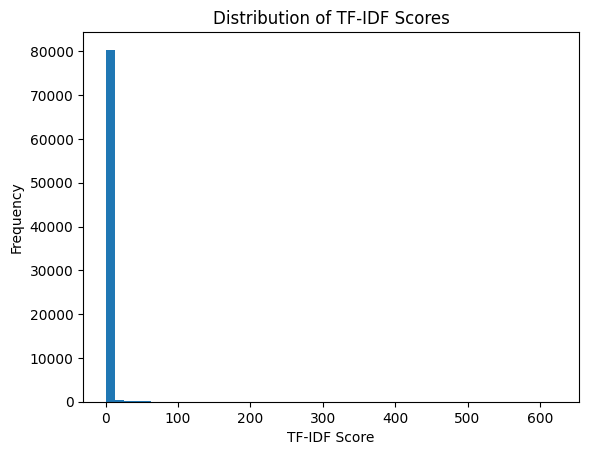

In [ ]:
# Plot the distribution of the scores
# Visualization
plt.hist(text_data_scores, bins=50, alpha=1)
# Visualization
plt.title("Distribution of TF-IDF Scores")
# Visualization
plt.xlabel("TF-IDF Score")
# Visualization
plt.ylabel("Frequency")
# Visualization
plt.show()


In [ ]:
# Imports: libraries for data, ML/NLP, and plotting
# Numerical / scientific computation
from scipy.stats import gaussian_kde
# Function: find_mode — see inline logic for details
def find_mode(data):
    kde = gaussian_kde(data)
# Numerical / scientific computation
    x = np.linspace(min(data), max(data), 1000)
    y = kde.evaluate(x)
# Numerical / scientific computation
    max_idx = np.argmax(y)
    mode = x[max_idx]
    return mode


In [ ]:
# Numerical / scientific computation
text_data_percentile = np.percentile(text_data_scores, 25)  # 10th percentile

text_data_mode_score = find_mode(text_data_scores)

text_data_threshold_score = text_data_percentile

text_data_reduced_indices = text_data_scores <= text_data_threshold_score
text_data_reduced_terms = text_data_terms[text_data_reduced_indices]
text_data_reduced_scores = text_data_scores[text_data_reduced_indices]

text_data_reduced_terms_df = pd.DataFrame({
    'Term': text_data_reduced_terms,
    'TF-IDF': text_data_reduced_scores
})

text_data_reduced_vocabulary = text_data_reduced_terms_df['Term'].tolist()

reduced_text_data_terms = [word for word in text_data_terms if word not in text_data_reduced_vocabulary]

filtered_text_data = [[word for word in document if word not in text_data_reduced_vocabulary]
                      for document in processsed_text_data]



In [ ]:
print(len(reduced_text_data_terms))
print(len(text_data_terms))

60890
81305


In [ ]:
# Function: normalize — see inline logic for details
def normalize(value, min_val, max_val):
    """Normalize a value between 0 and 1 using min-max normalization."""
    if max_val == min_val:
        return 0  # Avoid division by zero
    return (value - min_val) / (max_val - min_val)

# Function: compute_egovernance_index — see inline logic for details
def compute_egovernance_index(counts_dict):
    """
    Computes the e-governance index using the formula:
    1/3 * (normalized(Count['Online Services']) + normalized(Count['Telecommunication Infrastructure']) + normalized(Count['Human Capital']))

    Parameters:
    - counts_dict (dict): A dictionary with category names as keys and count values as values

    Returns:
    - e_governance_index (float): The computed e-governance index
    """

    # Extract the count values from the dictionary
    counts = list(counts_dict.values())

    # Determine the min and max values for normalization
    min_count = min(counts)
    max_count = max(counts)

    # Normalize each count value
    normalized_counts = [normalize(count, min_count, max_count) for count in counts]

    # Calculate the e-governance index
    e_governance_index = sum(normalized_counts) / 3

    return e_governance_index


In [ ]:
category_list = [["Online", "Digital", "Access", "Navigation", "Information", "Technology",
    "FAQs", "AI", "Chatbot", "W3C", "Data", "Portals", "Page", "Search",
    "Engine", "Site", "Framework", "Link", "Content", "Channels",
    "Feedback", "Browser"],["Telecommunication", "Mobile-cellular", "Subscription", "Cable", "Modem",
    "Wireless", "Broadband", "Telephone", "Analogue", "Postpaid", "Prepaid",
    "Computers", "Televisions", "Mobile", "Cellphone", "User", "Network", "Gadgets"],["Human", "Adult", "Literacy", "Enrolment", "School", "Child",
    "Education", "Enrolled", "Schooling", "Population", "Youth", "People"]]

category_names = ["Online Services","Telecommunication Infrastructure","Human Capital"]

In [ ]:
# Function: compute_similarity — see inline logic for details
def compute_similarity(category, documents, model):
    category_similarities = []
    for document in documents:
        if not document:  # Check if the document is empty
            sim_score = 0  # Assign a default score of 0 for empty documents
        else:
            try:
                sim_score = model.n_similarity(document, category)
            except KeyError:  # Handle words not in the model's vocabulary
                sim_score = 0
        category_similarities.append(sim_score)
    return category_similarities


In [ ]:
fasttext_model = KeyedVectors.load_word2vec_format('/content/drive/My Drive/Thesis Codes/wiki-news-300d-1M.vec', binary=False)

In [ ]:
# File path to the word similarity dataset
word_sim_path = "/content/drive/My Drive/Thesis Codes/wordsim353crowd.tsv"
# Load tabular data into a pandas DataFrame
wordsim_df = pd.read_csv('/content/drive/My Drive/Thesis Codes/wordsim353crowd.csv')
# Persist results to disk
wordsim_df.to_csv('/content/drive/My Drive/Thesis Codes/wordsim353crowd.tsv', sep='\t', index=False, header=False)

similarities = fasttext_model.evaluate_word_pairs(word_sim_path)
spearman_corr = similarities[0][0]
pearson_corr = similarities[1][0]
print("Spearman Correlation:", spearman_corr)
print("Pearson Correlation:", pearson_corr)


Spearman Correlation: 0.6361105762939401
Pearson Correlation: 0.6242660527505912


In [ ]:
google_model = KeyedVectors.load_word2vec_format('/content/drive/My Drive/Thesis Codes/Pretrained Models/word2vec-google-news-300.gz', binary=True)

In [ ]:
similarities = google_model.evaluate_word_pairs(word_sim_path)
spearman_corr = similarities[0][0]
pearson_corr = similarities[1][0]
print("Spearman Correlation:", spearman_corr)
print("Pearson Correlation:", pearson_corr)

Spearman Correlation: 0.6309060227466561
Pearson Correlation: 0.61940399464385


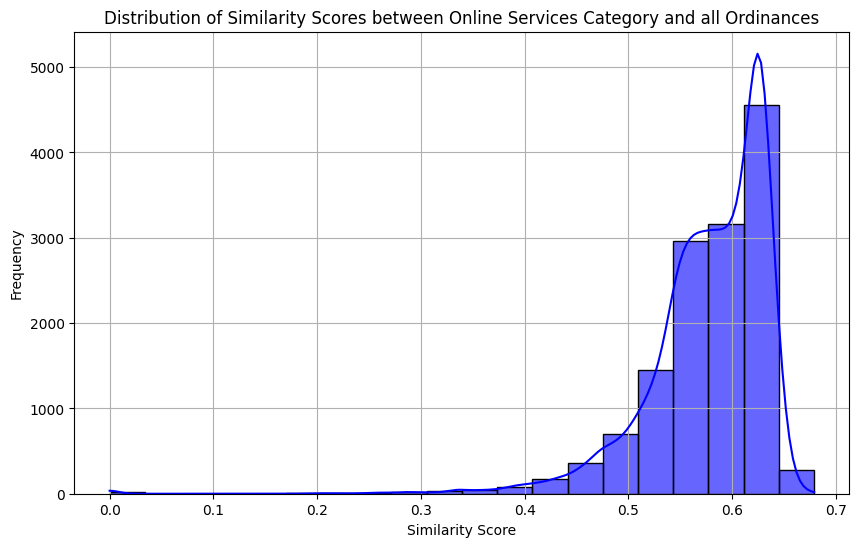

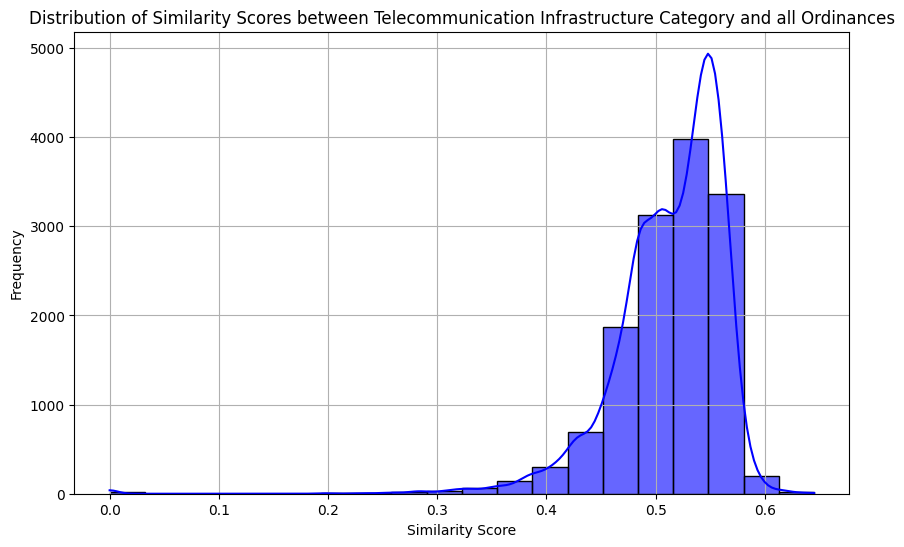

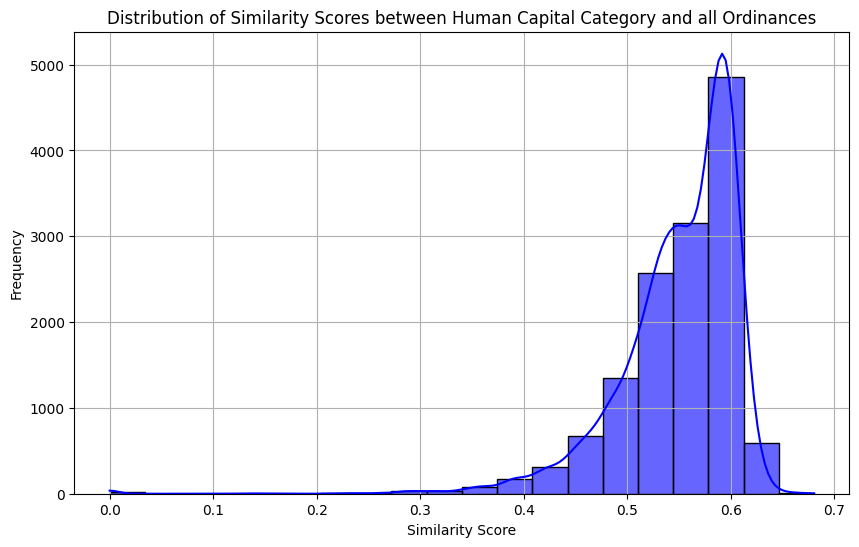

In [ ]:
#For online services:
similarities1 = compute_similarity(category_list[0], filtered_text_data, fasttext_model)
# Visualization
plt.figure(figsize=(10, 6))
# Visualization
sns.histplot(similarities1, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Visualization
plt.title("Distribution of Similarity Scores between Online Services Category and all Ordinances")
# Visualization
plt.xlabel("Similarity Score")
# Visualization
plt.ylabel("Frequency")
# Visualization
plt.grid(True)
# Visualization
plt.show()

#For telecommunication infrastractures:
similarities2 = compute_similarity(category_list[1], filtered_text_data, fasttext_model)
# Visualization
plt.figure(figsize=(10, 6))
# Visualization
sns.histplot(similarities2, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Visualization
plt.title("Distribution of Similarity Scores between Telecommunication Infrastructure Category and all Ordinances")
# Visualization
plt.xlabel("Similarity Score")
# Visualization
plt.ylabel("Frequency")
# Visualization
plt.grid(True)
# Visualization
plt.show()

#For human capital:
similarities3 = compute_similarity(category_list[2], filtered_text_data, fasttext_model)
# Visualization
plt.figure(figsize=(10, 6))
# Visualization
sns.histplot(similarities3, bins=20, kde=True, color='blue', edgecolor='black', alpha=0.6)
# Visualization
plt.title("Distribution of Similarity Scores between Human Capital Category and all Ordinances")
# Visualization
plt.xlabel("Similarity Score")
# Visualization
plt.ylabel("Frequency")
# Visualization
plt.grid(True)
# Visualization
plt.show()


In [ ]:
# Import numpy if not already imported
# Imports: libraries for data, ML/NLP, and plotting
import numpy as np

# Compute summary statistics for TF-IDF scores
# Numerical / scientific computation
min_score = np.min(similarities3)
# Numerical / scientific computation
max_score = np.max(similarities3)
range_score = max_score - min_score
# Numerical / scientific computation
mean_score = np.mean(similarities3)
# Numerical / scientific computation
first_quantile = np.percentile(similarities3, 25)
# Numerical / scientific computation
second_quantile = np.percentile(similarities3, 50)  # Median
# Numerical / scientific computation
third_quantile = np.percentile(similarities3, 75)
# Numerical / scientific computation
std_deviation = np.std(similarities3)

# Display results
print("Min Similarity Score:", min_score)
print("Max Similarity Score:", max_score)
print("Range:", range_score)
print("Mean:", mean_score)
print("1st Quantile:", first_quantile)
print("2nd Quantile (Median):", second_quantile)
print("3rd Quantile (75th percentile):", third_quantile)
print("Standard Deviation:", std_deviation)


Min Similarity Score: 0.0
Max Similarity Score: 0.680492639541626
Range: 0.680492639541626
Mean: 0.5495383469996311
1st Quantile: 0.5229365825653076
2nd Quantile (Median): 0.5625976920127869
3rd Quantile (75th percentile): 0.5909959077835083
Standard Deviation: 0.05904176683522379


In [ ]:
# Loop through each similarity list
google_similarities_all = [similarities1, similarities2, similarities3]
google_category_thresholds = []
for idx, sim in enumerate(google_similarities_all):
    mode = find_mode(sim)

    # Set thresholds as a percentage range around the mode
    range_percentage = 0.01   #Example: 3% around the mode
    low_threshold = mode - (mode * range_percentage)
    high_threshold = mode + (mode * range_percentage)

    # Add thresholds to the list as a tuple
    google_category_thresholds.append((low_threshold, high_threshold))

    # Print results
    print(f"--- Statistics for Similarities List: {category_names[idx]} ---")
    print(f"Mode (Peak value): {mode}")
    print(f"Low Threshold: {low_threshold}")
    print(f"High Threshold: {high_threshold}")
    print()

--- Statistics for Similarities List: Online Services ---
Mode (Peak value): 0.6247958410251606
Low Threshold: 0.618547882614909
High Threshold: 0.6310437994354122

--- Statistics for Similarities List: Telecommunication Infrastructure ---
Mode (Peak value): 0.5483303787829997
Low Threshold: 0.5428470749951697
High Threshold: 0.5538136825708297

--- Statistics for Similarities List: Human Capital ---
Mode (Peak value): 0.5919400438054785
Low Threshold: 0.5860206433674237
High Threshold: 0.5978594442435333



In [ ]:
# Dictionary to keep track of classifications and category counts
google_category_classifications = {i: [] for i in range(len(filtered_text_data[9361:10205]))}  # For per ordinance
google_category_counts = {j: 0 for j in range(len(category_list))}  # Initialize count for each category
unclassified_ordinance_count = 0  # Counter for ordinances not classified into any category

for i, ordinance in enumerate(filtered_text_data[9361:10205]):  # For per ordinance
    print(f"Processing ordinance {i}: Content: {ordinance}")

    if not ordinance:  # Check if the ordinance is empty
        print(f"Ordinance {i} is empty and cannot be classified.")
        continue  # Skip this iteration if the list is empty

    for j, category in enumerate(category_list):
        # Compute similarity of the current ordinance to the current category
        google_similarities = compute_similarity(category, [ordinance], fasttext_model)
        google_sim_score = google_similarities[0]  # Single similarity score since we pass one ordinance at a time
        print(f"Ordinance {i} has similarity {google_sim_score} with category {j}")

        # Check if the similarity score falls within the threshold range for classification
        lower_bound, upper_bound = google_category_thresholds[j]
        if lower_bound <= google_sim_score:
            google_category_classifications[i].append((j, google_sim_score))
            google_category_counts[j] += 1  # Increment the count for this category

    # Check if the current ordinance wasn't classified into any category
    if not google_category_classifications[i]:
        unclassified_ordinance_count += 1

# Output results
print("\nFinal classification results:")
for ordinance_index, classifications in google_category_classifications.items():
    if classifications:
        for classification in classifications:
            category_index, similarity_score = classification
            print(f"Ordinance {ordinance_index} is classified into category {category_index} with similarity {similarity_score}")
    else:
        print(f"Ordinance {ordinance_index} is not classified into any category")

# Print the final count of classifications per category
print("\nCount of ordinances per category:")
for category_index, count in google_category_counts.items():
    print(f"Category {category_index}: {count} ordinances classified")

# Print count of unclassified ordinances
print(f"\nTotal ordinances not classified into any category: {unclassified_ordinance_count}")


Processing ordinance 0: Content: ['institution', 'capit', 'assist', 'program', 'social', 'servic', 'develop', 'depart', 'disadvantag', 'sector', 'provid', 'fund', 'therefor', 'purpos']
Ordinance 0 has similarity 0.5881333351135254 with category 0
Ordinance 0 has similarity 0.5173028707504272 with category 1
Ordinance 0 has similarity 0.572299599647522 with category 2
Processing ordinance 1: Content: ['establish', 'klinika', 'eastwood', 'comprehens', 'sexual', 'health', 'care', 'clinic', 'locat', 'ground', 'floor', 'citywalk', 'park', 'cyberpark', 'rodriguez', 'avenu', 'bagumbayan', 'district', 'depart']
Ordinance 1 has similarity 0.5618535280227661 with category 0
Ordinance 1 has similarity 0.5086820721626282 with category 1
Ordinance 1 has similarity 0.5949872136116028 with category 2
Processing ordinance 2: Content: ['expand', 'scholarship', 'program', 'amend']
Ordinance 2 has similarity 0.521772027015686 with category 0
Ordinance 2 has similarity 0.43017542362213135 with category 1


In [ ]:
#Google word vectors
e_governance_index = compute_egovernance_index(google_category_counts)
print(f"E-Governance Index using pre-trained model: {e_governance_index}")

TypeError: 'int' object is not callable

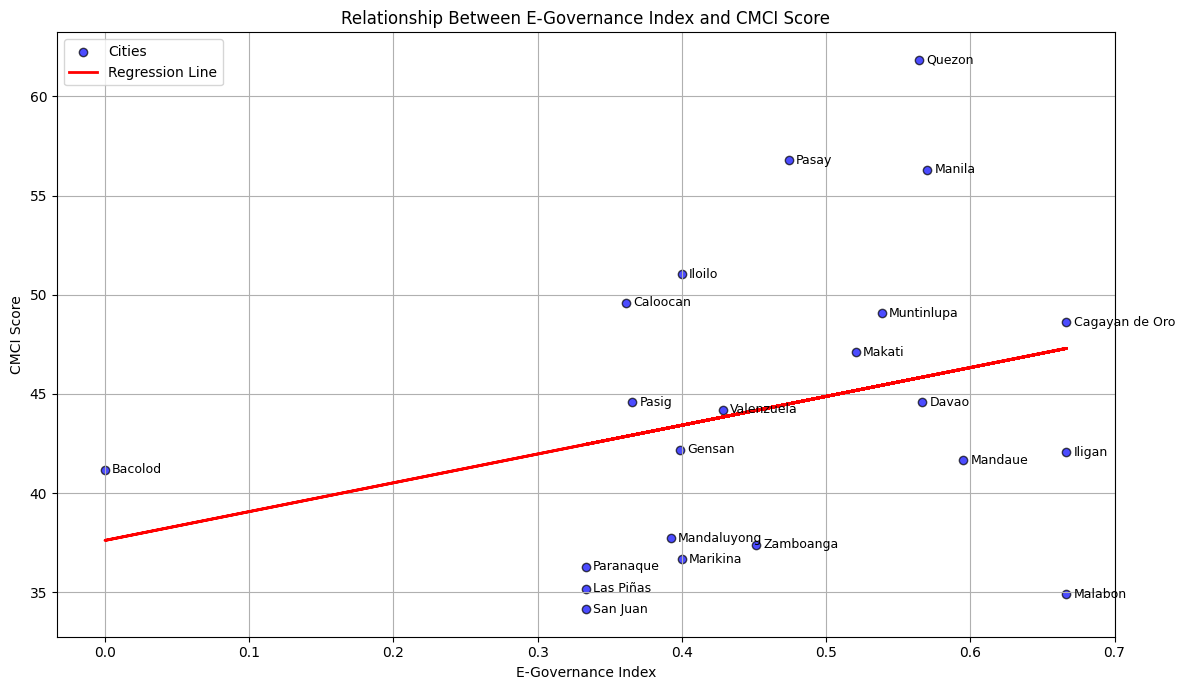

14.524341521284239
37.615690082896506


In [ ]:
# Imports: libraries for data, ML/NLP, and plotting
import matplotlib.pyplot as plt
# Imports: libraries for data, ML/NLP, and plotting
import numpy as np

# Data
e_gov_index = [
    0.474025974, 0.4, 0.3333333333, 0.6666666667, 0.3333333333,
    0.6666666667, 0.3611111111, 0.5386313466, 0.5666666667, 0.3655913978,
    0.5206349206, 0.5643939394, 0.3333333333, 0.3921568627, 0.6666666667,
    0.5701754386, 0.0, 0.5952380952, 0.4285714286, 0.4,
    0.3988095238, 0.4513888889
]

cmci_scores = [
    56.7826, 51.0439, 36.3001, 48.612, 35.1899,
    42.0494, 49.5927, 49.0816, 44.5875, 44.5875,
    47.1135, 61.8475, 34.1455, 37.7354, 34.8983,
    56.2923, 41.1841, 41.6661, 44.2105, 36.6775,
    42.1879, 37.4007
]

cities = [
    'Pasay','Iloilo','Paranaque','Cagayan de Oro','Las Piñas','Iligan',
    'Caloocan','Muntinlupa','Davao','Pasig','Makati','Quezon','San Juan',
    'Mandaluyong','Malabon','Manila','Bacolod','Mandaue','Valenzuela',
    'Marikina','Gensan','Zamboanga'
]

# Compute regression line
# Numerical / scientific computation
x = np.array(e_gov_index)
# Numerical / scientific computation
y = np.array(cmci_scores)
# Model fit/transform step
# Numerical / scientific computation
slope, intercept = np.polyfit(x, y, 1)
regression_line = slope * x + intercept

# Plotting
# Visualization
plt.figure(figsize=(12, 7))
# Visualization
plt.scatter(x, y, color='blue', edgecolor='black', alpha=0.7, label='Cities')

# Add city labels
for i, city in enumerate(cities):
# Visualization
    plt.text(x[i] + 0.005, y[i], city, fontsize=9, ha='left', va='center')

# Visualization
plt.plot(x, regression_line, color='red', linewidth=2, label='Regression Line')
# Visualization
plt.title('Relationship Between E-Governance Index and CMCI Score')
# Visualization
plt.xlabel('E-Governance Index')
# Visualization
plt.ylabel('CMCI Score')
# Visualization
plt.legend()
# Visualization
plt.grid(True)
# Visualization
plt.tight_layout()

# Show plot
# Visualization
plt.show()
print(slope)
print(intercept)


In [ ]:
# Function: print_ordinance_classification — see inline logic for details
def print_ordinance_classification(ordinance_index, ordinance_index_2, category_classifications, category_names):
    print(f"Ordinance {ordinance_index}:{text_data[ordinance_index_2]}")
    if ordinance_index in category_classifications:
        classifications = category_classifications[ordinance_index]
        if classifications:
            print(f"Ordinance {ordinance_index} is classified into the following categories:")
            for category_index, similarity_score in classifications:
                print(f"- {category_names[category_index]} with similarity {similarity_score}")
        else:
            print(f"Ordinance {ordinance_index} is not classified into any category.")
    else:
        print(f"No data available for Ordinance {ordinance_index}.")

# Example usage
ordinance_index = 670  # Specify the index of the ordinance you want to check
ordinance_index_2 = 9361+ordinance_index
category_names = ['Online Services', 'Telecommunication Infrastructure', 'Human Capital']  # Names of categories
print_ordinance_classification(ordinance_index,ordinance_index_2, google_category_classifications, category_names)
print(processsed_text_data[ordinance_index_2])


Ordinance 670:SP-2641, S-2017: AN ORDINANCE AMENDING ORDINANCE NO. SP-2285, S-2014, ENTITLED “AN ORDINANCE REGULATING THE OPERATION OF ELECTRONIC GAMES (E-GAMES), BINGO GAMES, AND OTHER GAMES OF CHANCE, WHETHER MANUAL, MECHANICAL, ELECTRONIC INTERNET BROADBAND OR OTHERWISE, OPERATING WITHIN THE TERRITORIAL JURISDICTION OF QUEZON CITY AND PROVIDING PENALTIES FOR VIOLATIONS THEREOF.” nan
Ordinance 670 is classified into the following categories:
- Online Services with similarity 0.6460371017456055
- Telecommunication Infrastructure with similarity 0.6390966773033142
['amend', 'entitl', 'regul', 'oper', 'electron', 'game', 'egam', 'bingo', 'chanc', 'manual', 'mechan', 'internet', 'broadband', 'territori', 'jurisdict', 'provid', 'penalti', 'violat', 'thereof']


In [ ]:
# Generate random window sizes (integers) between 2 and 10
tokens_cleaned = filtered_text_data + category_list
window_sizes = [12,15]

# Generate vector sizes with increments of 50 between 50 and 350
vector_sizes = [50,180,250,290]

# Loop over combinations of window size and vector size
for window in window_sizes:
    for vector_size in vector_sizes:
        start_time = time.time()  # Start time to track training duration

        # Train the model
        model = Word2Vec(
                sentences=tokens_cleaned,
                sg=1,                     # Skip-Gram (1) or CBOW (0)
                vector_size=vector_size,  # Dimensionality of embeddings
                window=window,            # Context window size
                workers=10,                # Parallelization
                epochs=30,                # Number of epochs
                hs=0,
                negative = 5, # Hierarchical softmax (1) or negative sampling (0)             # Number of negative samples
                alpha=0.03,              # Initial learning rate
                min_alpha=0.0007,         # Minimum learning rate
                sample=1e-5,              # Subsampling rate for frequent words
                seed=42,
                compute_loss=True # Reproducibility
            )

        # Print time taken for each combination
        print(f"Model with window={window} and vector_size={vector_size} trained in "
              f"{(time.time() - start_time) / 60:.2f} mins")

        # Save the model to a specific path
        model_path = f'/content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model{window}_vector{vector_size}.model'
        model.save(model_path)
        print(f"Model saved to {model_path}\n")


# Define the folder where the models are saved
models_folder = '/content/drive/My Drive/Thesis Codes/Pretrained Models'

# Get a list of all the .model files in the folder
model_paths = [os.path.join(models_folder, f) for f in os.listdir(models_folder) if f.endswith('.model')]

# File path to the word similarity dataset
word_sim_path = "/content/drive/My Drive/Thesis Codes/wordsim353crowd.tsv"
# Load tabular data into a pandas DataFrame
wordsim_df = pd.read_csv('/content/drive/My Drive/Thesis Codes/wordsim353crowd.csv')
# Persist results to disk
wordsim_df.to_csv('/content/drive/My Drive/Thesis Codes/wordsim353crowd.tsv', sep='\t', index=False, header=False)

# Initialize variables to track the best model based on Spearman and Pearson correlations
best_spearman_score = -1  # Start with a low baseline
best_spearman_model = ""

best_pearson_score = -1  # Start with a low baseline
best_pearson_model = ""

# Loop through each model file and evaluate it
for model_path in model_paths:
    # Load the model
    model = Word2Vec.load(model_path)

    # Evaluate the model
    similarities = model.wv.evaluate_word_pairs(word_sim_path)

    # Extract the Spearman and Pearson correlation scores
    spearman_corr = similarities[0][0]
    pearson_corr = similarities[1][0]

    # Print the results for each model
    print(f"Results for model: {model_path}")
    print("Spearman Correlation:", spearman_corr)
    print("Pearson Correlation:", pearson_corr)
    print("-" * 50)  # Divider for better readability

    # Update the best Spearman score and model if the current one is higher
    if spearman_corr > best_spearman_score:
        best_spearman_score = spearman_corr
        best_spearman_model = model_path

    # Update the best Pearson score and model if the current one is higher
    if pearson_corr > best_pearson_score:
        best_pearson_score = pearson_corr
        best_pearson_model = model_path

# Output the models with the highest Spearman and Pearson correlation scores
print("\nModel with the highest Spearman Correlation:")
print(f"Model: {best_spearman_model}")
print(f"Spearman Correlation: {best_spearman_score}")

print("\nModel with the highest Pearson Correlation:")
print(f"Model: {best_pearson_model}")
print(f"Pearson Correlation: {best_pearson_score}")


Model with window=12 and vector_size=50 trained in 1.20 mins
Model saved to /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model12_vector50.model

Model with window=12 and vector_size=180 trained in 1.54 mins
Model saved to /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model12_vector180.model

Model with window=12 and vector_size=250 trained in 1.78 mins
Model saved to /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model12_vector250.model

Model with window=12 and vector_size=290 trained in 1.67 mins
Model saved to /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model12_vector290.model

Model with window=15 and vector_size=50 trained in 1.45 mins
Model saved to /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model15_vector50.model

Model with window=15 and vector_size=180 trained in 1.77 mins
Model saved to /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model15_vector180.mod

/usr/local/lib/python3.11/dist-packages/gensim/models/keyedvectors.py:1510: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = stats.spearmanr(similarity_gold, similarity_model)
/usr/local/lib/python3.11/dist-packages/gensim/models/keyedvectors.py:1511: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = stats.pearsonr(similarity_gold, similarity_model)


Results for model: /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model9_vector0.model
Spearman Correlation: nan
Pearson Correlation: nan
--------------------------------------------------
Results for model: /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model9_vector40.model
Spearman Correlation: 0.291897662867811
Pearson Correlation: 0.37029562203478983
--------------------------------------------------
Results for model: /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model9_vector20.model
Spearman Correlation: 0.25198795912722166
Pearson Correlation: 0.3230727361555433
--------------------------------------------------
Results for model: /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model6_vector0.model
Spearman Correlation: nan
Pearson Correlation: nan
--------------------------------------------------


/usr/local/lib/python3.11/dist-packages/gensim/models/keyedvectors.py:1510: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = stats.spearmanr(similarity_gold, similarity_model)
/usr/local/lib/python3.11/dist-packages/gensim/models/keyedvectors.py:1511: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = stats.pearsonr(similarity_gold, similarity_model)


Results for model: /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model6_vector20.model
Spearman Correlation: 0.2931554075732004
Pearson Correlation: 0.3542387962468077
--------------------------------------------------
Results for model: /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model8_vector0.model
Spearman Correlation: nan
Pearson Correlation: nan
--------------------------------------------------


/usr/local/lib/python3.11/dist-packages/gensim/models/keyedvectors.py:1510: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = stats.spearmanr(similarity_gold, similarity_model)
/usr/local/lib/python3.11/dist-packages/gensim/models/keyedvectors.py:1511: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = stats.pearsonr(similarity_gold, similarity_model)


Results for model: /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model12_vector70.model
Spearman Correlation: 0.27396940458157204
Pearson Correlation: 0.3481428730735822
--------------------------------------------------
Results for model: /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model12_vector30.model
Spearman Correlation: 0.33998295012731183
Pearson Correlation: 0.41575762924955495
--------------------------------------------------
Results for model: /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model3_vector70.model
Spearman Correlation: 0.22661468656602363
Pearson Correlation: 0.2828336741320362
--------------------------------------------------
Results for model: /content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model3_vector30.model
Spearman Correlation: 0.24863159037385188
Pearson Correlation: 0.2914366109970656
--------------------------------------------------
Results for model: /content/drive/My 

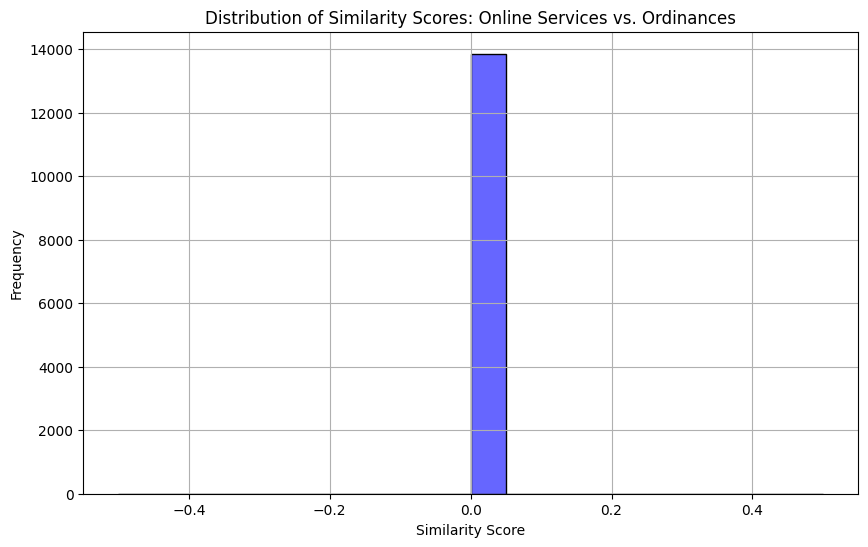

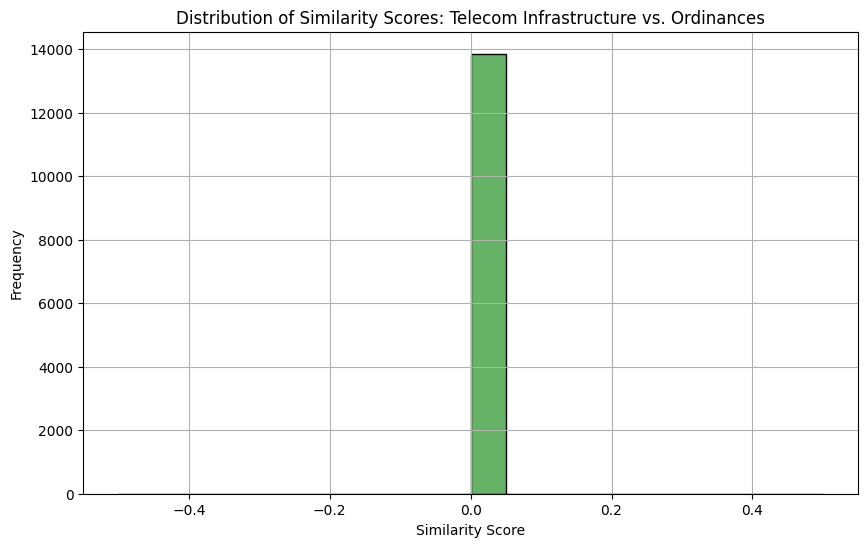

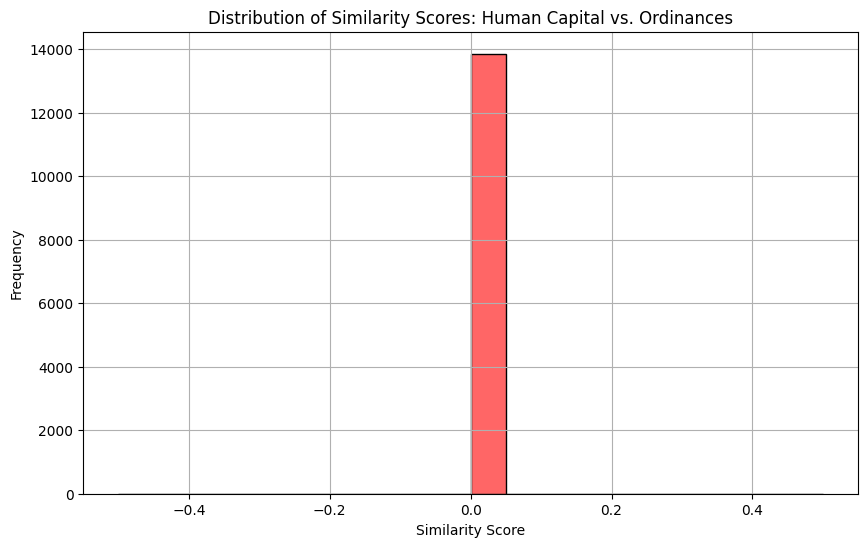

In [ ]:
# Imports: libraries for data, ML/NLP, and plotting
from gensim.models import KeyedVectors
# Imports: libraries for data, ML/NLP, and plotting
import matplotlib.pyplot as plt
# Imports: libraries for data, ML/NLP, and plotting
import seaborn as sns

# Load the pretrained Word2Vec model
model_path = "/content/drive/My Drive/Thesis Codes/Pretrained Models/pretrained_model12_vector50.model"
pretrained_model = KeyedVectors.load(model_path)  # Use .kv format
keyed_vectors = pretrained_model.wv

# Function to compute similarity scores
# Function: compute_similarity2 — see inline logic for details
def compute_similarity2(category, documents, model):
    category_similarities = []

    for document in documents:
        if not document:  # Empty document check
            sim_score = 0
        else:
            # Keep only words present in the model
            valid_doc_words = [word for word in document if word in model]
            valid_cat_words = [word for word in category if word in model]

            if valid_doc_words and valid_cat_words:  # Ensure non-empty lists
                sim_score = model.n_similarity(valid_doc_words, valid_cat_words)
            else:
                sim_score = 0  # Assign 0 if no valid words

        category_similarities.append(sim_score)

    return category_similarities

# Define category names and colors for plots
category_names = ["Online Services", "Telecom Infrastructure", "Human Capital"]
colors = ["blue", "green", "red"]

# Loop through categories, compute similarities, and plot results
for i, category in enumerate(category_list):
    similarities = compute_similarity2(category, filtered_text_data, keyed_vectors)

# Visualization
    plt.figure(figsize=(10, 6))
# Visualization
    sns.histplot(similarities, bins=20, kde=True, color=colors[i], edgecolor='black', alpha=0.6)
# Visualization
    plt.title(f"Distribution of Similarity Scores: {category_names[i]} vs. Ordinances")
# Visualization
    plt.xlabel("Similarity Score")
# Visualization
    plt.ylabel("Frequency")
# Visualization
    plt.grid(True)
# Visualization
    plt.show()
